What Stage 2 does and why it's structured this waygmsh takes the STL from Stage 1 and produces a volumetric tetrahedral mesh that FEniCSx can solve on. This is where most pipelines silently break — STL import into gmsh is lossy by default, and a bad mesh (inverted elements, poor aspect ratios, gaps at boundaries) produces garbage FEA results with no obvious error.The data flow for this stage is:outputs/meshes/<name>_stage01.json   ← handoff from Stage 1
outputs/meshes/<name>.stl            ← geometry from OpenSCAD
        ↓
src/meshing/gmsh_pipeline.py         ← STL import, repair, meshing
src/meshing/mesh_quality.py          ← quality metrics and pass/fail thresholds
        ↓
outputs/meshes/<name>.msh            ← gmsh native format
outputs/meshes/<name>.xdmf           ← FEniCSx-readable format (+ .h5)
outputs/meshes/<name>_stage02.json   ← handoff to Stage 3The split between gmsh_pipeline.py and mesh_quality.py is intentional — quality checking is independently testable in tests/test_mesh_quality.py without needing to re-run the full mesh generation.

Cell 0 — Parameters (tag: parameters)

In [1]:
# Cell 0 — tagged: parameters
import os
os.chdir("/workspace")

import sys
sys.path.insert(0, "/workspace")

STAGE01_HANDOFF  = None   # override to skip auto-detection
VERBOSITY        = 2      # gmsh verbosity: 0=silent, 5=debug
ANGLE_DEG        = 20.0   # surface classification angle threshold
ALGORITHM_3D     = 4      # 1=Delaunay, 4=Frontal, 10=HXT parallel
QUALITY_STRICT   = False   # if True, abort on quality failures

Cell 1 — Load Stage 1 handoff

In [2]:
# Cell 1 — Read handoff from 01_geometry_openscad.ipynb
import json
from pathlib import Path

# Auto-detect most recent stage01 handoff if not overridden
if STAGE01_HANDOFF is None:
    candidates = sorted(Path("outputs/meshes").glob("*_stage01.json"))
    if not candidates:
        raise FileNotFoundError(
            "No stage01 handoff found in outputs/meshes/. "
            "Run 01_geometry_openscad.ipynb first."
        )
    handoff_path = candidates[-1]
else:
    handoff_path = Path(STAGE01_HANDOFF)

handoff = json.loads(handoff_path.read_text())
print(f"Loaded handoff: {handoff_path}")
print(json.dumps(handoff, indent=2))

stl_path            = Path(handoff["stl_path"])
part_name           = handoff["part_name"]
target_element_size = handoff["mesh_hints"]["target_element_size"]
load_hints          = handoff["load_hints"]

assert stl_path.exists(), f"STL not found: {stl_path}"
print(f"\nSTL confirmed: {stl_path} ({stl_path.stat().st_size // 1024} KB)")

Loaded handoff: outputs/meshes/base_part_stage01.json
{
  "stage": "01_geometry",
  "part_name": "base_part",
  "stl_path": "outputs/meshes/base_part.stl",
  "stl_size_kb": 101.82,
  "duration_s": 0.238,
  "mesh_hints": {
    "target_element_size": 8.0,
    "refinement_regions": []
  },
  "load_hints": {
    "primary_face": "top",
    "load_magnitude_n": 13000.0
  }
}

STL confirmed: outputs/meshes/base_part.stl (101 KB)


Cell 2 — Run meshing pipeline

In [3]:
# Cell 2 — Generate volumetric mesh
from src.meshing.gmsh_pipeline import run_meshing_pipeline

result = run_meshing_pipeline(
    stl_path=stl_path,
    part_name=part_name,
    output_dir="outputs/meshes",
    target_element_size=target_element_size,
    verbosity=VERBOSITY,
    angle_deg=ANGLE_DEG,
    algorithm_3d=ALGORITHM_3D,
)

print(f"Success:          {result.success}")
print(f"Duration:         {result.duration_s}s")
print(f"Nodes:            {result.n_nodes}")
print(f"Elements:         {result.n_elements}")
print(f"Boundary tris:    {result.n_boundary_tris}")
print(f"MSH:              {result.msh_path}")
print(f"XDMF:             {result.xdmf_path}")
if result.warnings:
    print(f"\nWarnings:")
    for w in result.warnings:
        print(f"  ⚠ {w}")

result.raise_if_failed()


Success:          True
Duration:         10.338s
Nodes:            16284
Elements:         67305
Boundary tris:    17998
MSH:              outputs/meshes/base_part.msh
XDMF:             outputs/meshes/base_part.xdmf


Cell 3 — Quality check

In [4]:
# Cell 3 — Mesh quality gate
# Failures here mean Stage 3 (FEniCSx) will either abort or give wrong results.
from src.meshing.mesh_quality import check_mesh_quality, QualityThresholds

thresholds = QualityThresholds(
    max_aspect_ratio=8.0,
    max_aspect_ratio_fail=30.0,
    min_dihedral_deg=5.0,
)

quality = check_mesh_quality(result.msh_path, thresholds)
print(quality.summary())

if QUALITY_STRICT and not quality.passed:
    raise RuntimeError(
        "Mesh quality below threshold — aborting before Stage 3.\n"
        "Options:\n"
        "  1. Reduce target_element_size in scad/params.json\n"
        "  2. Switch algorithm_3d to 4 (Frontal) in this notebook\n"
        "  3. Set QUALITY_STRICT=False to proceed anyway (not recommended)"
    )

Elements:          67305
Aspect ratio:      mean=4.70  max=51.45  p95=6.75
Min dihedral:      4.9°
Inverted elements: 0
Passed:            False
  ✗ Max aspect ratio 51.4 exceeds hard limit 30.0
  ✗ Min dihedral 4.9° below threshold 5.0°


Cell 4 — Visualize mesh

Preview saved: outputs/reports/base_part_mesh.png


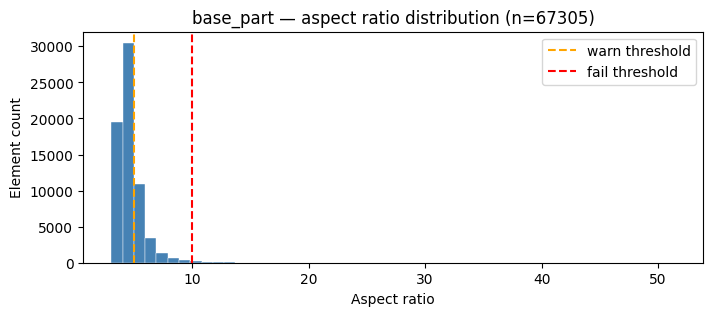

Histogram saved: outputs/reports/base_part_aspect_ratio.png


In [5]:
# Cell 4 — Headless mesh preview → outputs/reports/
import pyvista as pv
from pathlib import Path

pv.OFF_SCREEN = True

# Read the XDMF for preview — pyvista can read it directly
mesh = pv.read(str(result.xdmf_path))

report_dir = Path("outputs/reports")
png_path = report_dir / f"{part_name}_mesh.png"

pl = pv.Plotter()
pl.add_mesh(mesh, show_edges=True, color="lightsteelblue", opacity=0.85)
pl.add_axes()
pl.screenshot(str(png_path))
pl.close()

print(f"Preview saved: {png_path}")

# Aspect ratio histogram — useful for spotting concentrated bad elements
import matplotlib.pyplot as plt
import numpy as np
from src.meshing.mesh_quality import _tet_aspect_ratios
import gmsh

gmsh.initialize()
gmsh.option.setNumber("General.Verbosity", 0)
gmsh.open(str(result.msh_path))
node_tags, coords, _ = gmsh.model.mesh.getNodes()
points = coords.reshape(-1, 3)
_, _, elem_nodes = gmsh.model.mesh.getElements(dim=3)
tets = elem_nodes[0].reshape(-1, 4) - 1
ar = _tet_aspect_ratios(points, tets)
gmsh.finalize()

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(ar, bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(5.0, color="orange", linestyle="--", label="warn threshold")
ax.axvline(10.0, color="red", linestyle="--", label="fail threshold")
ax.set_xlabel("Aspect ratio")
ax.set_ylabel("Element count")
ax.set_title(f"{part_name} — aspect ratio distribution (n={len(ar)})")
ax.legend()
hist_path = report_dir / f"{part_name}_aspect_ratio.png"
plt.savefig(hist_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Histogram saved: {hist_path}")

Also make a note to come back to this after the full pipeline is validated — we can improve mesh quality by either increasing fn_curve in base_part.scad (smoother cylinder approximation for the holes) or adding mesh_hints.refinement_regions around the holes. 

Cell 5 — Write Stage 2 handoff

In [6]:
# Cell 5 — Write handoff for 03_fea_fenicsx.ipynb
import json
from dataclasses import asdict

handoff_out = {
    "stage":             "02_meshing",
    "part_name":         part_name,
    "stl_path":          str(stl_path),
    "msh_path":          str(result.msh_path),
    "xdmf_path":         str(result.xdmf_path),
    "xdmf_boundaries":   str(result.xdmf_path).replace(".xdmf", "_boundaries.xdmf"),
    "n_nodes":           result.n_nodes,
    "n_elements":        result.n_elements,
    "quality": {
        "aspect_ratio_mean": quality.aspect_ratio_mean,
        "aspect_ratio_max":  quality.aspect_ratio_max,
        "aspect_ratio_p95":  quality.aspect_ratio_p95,
        "min_dihedral_deg":  quality.min_dihedral_deg,
        "n_inverted":        quality.n_inverted,
        "passed":            quality.passed,
    },
    "load_hints":        load_hints,
}

handoff_path_out = Path("outputs/meshes") / f"{part_name}_stage02.json"
handoff_path_out.write_text(json.dumps(handoff_out, indent=2))
print(f"Handoff written: {handoff_path_out}")
print(json.dumps(handoff_out, indent=2))

Handoff written: outputs/meshes/base_part_stage02.json
{
  "stage": "02_meshing",
  "part_name": "base_part",
  "stl_path": "outputs/meshes/base_part.stl",
  "msh_path": "outputs/meshes/base_part.msh",
  "xdmf_path": "outputs/meshes/base_part.xdmf",
  "xdmf_boundaries": "outputs/meshes/base_part_boundaries.xdmf",
  "n_nodes": 16284,
  "n_elements": 67305,
  "quality": {
    "aspect_ratio_mean": 4.7,
    "aspect_ratio_max": 51.448,
    "aspect_ratio_p95": 6.748,
    "min_dihedral_deg": 4.92,
    "n_inverted": 0,
    "passed": false
  },
  "load_hints": {
    "primary_face": "top",
    "load_magnitude_n": 13000.0
  }
}


How Stage 2 connects to Stage 3
Two things travel forward in the handoff JSON:
xdmf_path and xdmf_boundaries — FEniCSx in 03_fea_fenicsx.ipynb reads these directly via dolfinx.io.XDMFFile. The volume mesh goes into the solver; the boundary mesh is used by src/fea/boundary_conditions.py to locate the tagged surfaces (top, bottom, sides) and apply the right constraints.
load_hints — the primary_face and load_magnitude_n values from scad/params.json that have been carried through both stages. src/fea/boundary_conditions.py uses primary_face to select which physical group tag to apply the Neumann (traction) boundary condition to, and load_magnitude_n as the force magnitude.
The physical group tags set in tag_physical_groups() are what make this work — bottom=3 (Dirichlet, fixed), top=2 (Neumann, load applied), sides=4 (free). If surface classification in Phase 1 goes wrong — typically because angle_deg is too coarse for the part geometry — these tags get mis-assigned and the FEA solve will give physically wrong results without crashing. The aspect ratio histogram in Cell 4 is your first signal that classification went wrong, because mis-classified surfaces produce degenerate boundary elements.